<a href="https://colab.research.google.com/github/princesapkota/Vegetable_image_classification/blob/main/2408837_princesapkota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
import zipfile

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
zip_path = '/content/drive/MyDrive/dataset.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Global variables based on the dataset details
IMG_SIZE = (224, 224) # Resolution mentioned in the brief
BATCH_SIZE = 32
NUM_CLASSES = 15

##STEP 1: Data Understanding & Preprocessing:
First, I will set up the ImageDataGenerator. According to the pdf, I need to apply normalization (rescale=1./255) to all sets, but data augmentation (rotation, flips, shifts, zooms) should only be applied to the training set to prevent overfitting and help the model generalize better.

In [4]:
# 1.Training Generator with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizing pixel values to 0-1
    rotation_range=20,        # Rotating images up to 20 degrees
    width_shift_range=0.2,    # Shifting horizontally
    height_shift_range=0.2,   # Shifting vertically
    horizontal_flip=True,     # Flipping images randomly
    zoom_range=0.2            # Randomly zooming in
)

# 2. Validation and Test Generators (Strictly NO augmentation, only normalization!)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flowing images from the directories
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\nLoading Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nLoading Testing Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Loading Training Data:
Found 15000 images belonging to 15 classes.

Loading Validation Data:
Found 3000 images belonging to 15 classes.

Loading Testing Data:
Found 3000 images belonging to 15 classes.


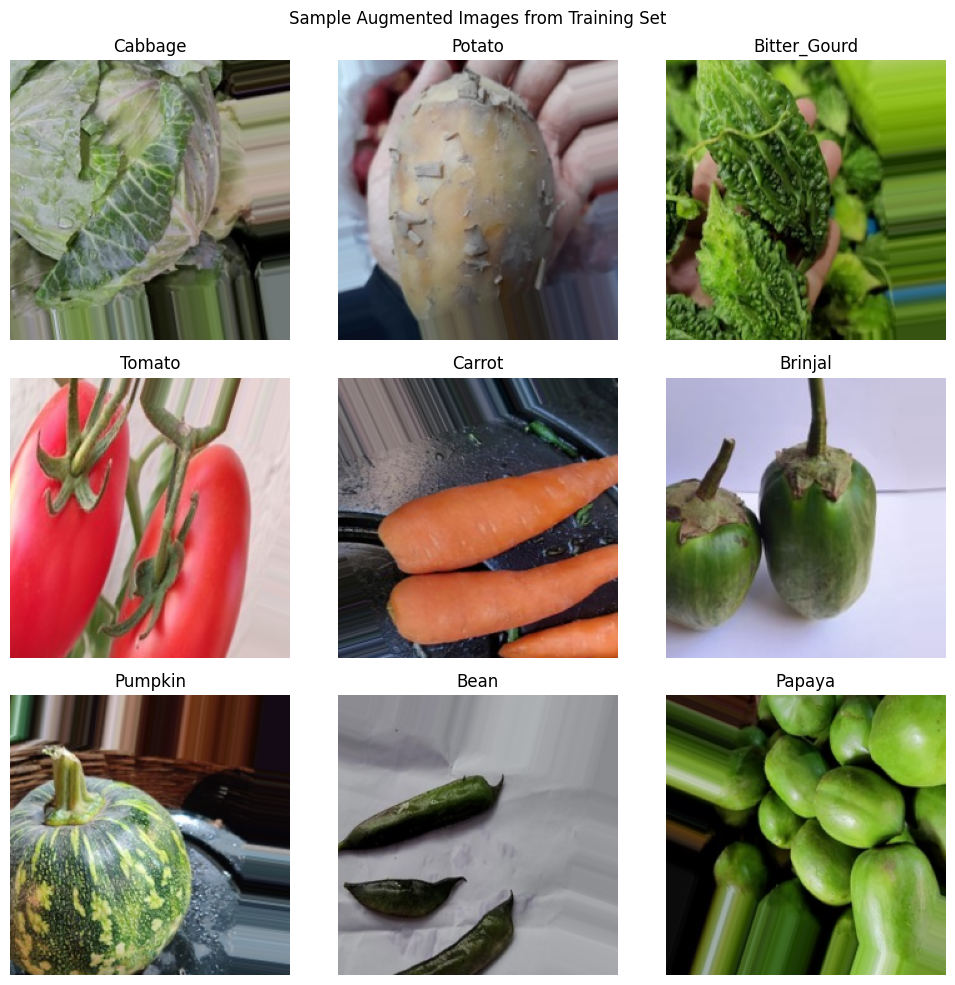

In [5]:
# Let's visualize a few sample images
class_names = list(train_generator.class_indices.keys())
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Finding the actual class name using the label index
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.suptitle("Sample Augmented Images from Training Set")
plt.tight_layout()
plt.show()

Helper Functions for Evaluation


In [6]:
def plot_training_history(history, model_name):
    """Plots training/validation accuracy and loss."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, generator, model_name):
    """Generates Classification Report and Confusion Matrix."""
    print(f"Evaluating {model_name} on Test Set")
    generator.reset() # Important to reset generator before predicting

    predictions = model.predict(generator, steps=len(generator))
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    print("\n1. Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("\n2. Confusion Matrix:\n")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.show()

STEP 2: Baseline CNN Model (From Scratch) :
Here I am building the baseline architecture specified in Part A. It's a standard CNN with 3 Conv blocks followed by 3 Dense layers.

In [7]:
# Constructing the baseline model as per the assignment pdf
baseline_model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax') # Softmax for 15 multi-class outputs
])

baseline_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,562,255 (169.99 MB)

 Trainable params: 44,562,255 (169.99 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS = 20

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_baseline.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting training for Baseline CNN")
baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

Starting training for Baseline CNN
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8433 - loss: 0.4689
Epoch 1: val_accuracy improved from None to 0.85200, saving model to best_baseline.keras

Epoch 1: finished saving model to best_baseline.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 426ms/step - accuracy: 0.8572 - loss: 0.4424 - val_accuracy: 0.8520 - val_loss: 0.4492
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8849 - loss: 0.3628
Epoch 2: val_accuracy improved from 0.85200 to 0.90333, saving model to best_baseline.keras

Epoch 2: finished saving model to best_baseline.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 438ms/step - accuracy: 0.8923 - loss: 0.3433 - val_accuracy: 0.9033 - val_loss: 0.3357
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9040 - loss: 0.3110
Epoch 3: val_accuracy improved from 0.90333 to 0.93200, saving model to best_baseline.keras

Epoch 3: finished saving model to best_baseline.keras
469/469 ━━━━━━━━━━━━━

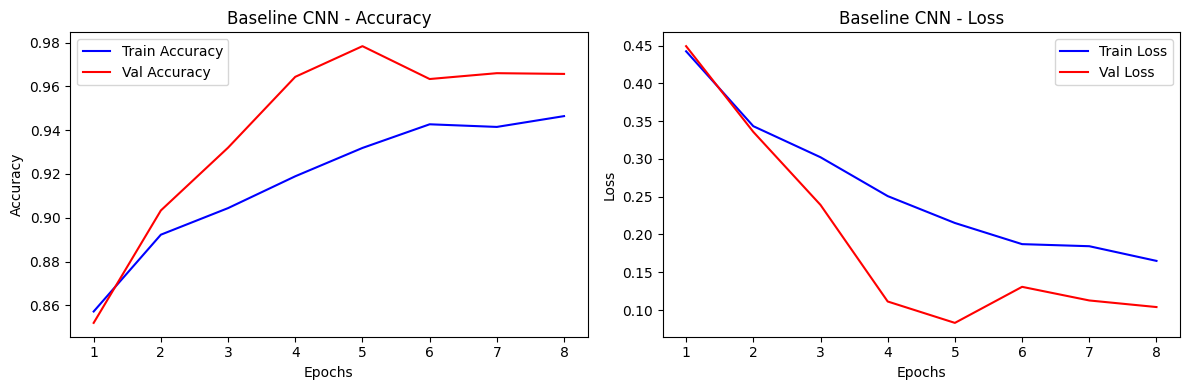

Evaluating Baseline CNN on Test Set
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step

1. Classification Report:

              precision    recall  f1-score   support

        Bean       0.97      0.96      0.97       200
Bitter_Gourd       0.99      0.97      0.98       200
Bottle_Gourd       0.99      0.99      0.99       200
     Brinjal       0.95      0.98      0.96       200
    Broccoli       0.97      0.97      0.97       200
     Cabbage       0.94      0.97      0.96       200
    Capsicum       1.00      0.98      0.99       200
      Carrot       0.99      0.99      0.99       200
 Cauliflower       0.97      0.96      0.96       200
    Cucumber       0.98      0.99      0.99       200
      Papaya       0.97      0.98      0.98       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.96      0.96      0.96       200
      Radish       0.99      1.00      1.00       200
      Tomato       0.99      0.94      0.96       200

    accuracy                  

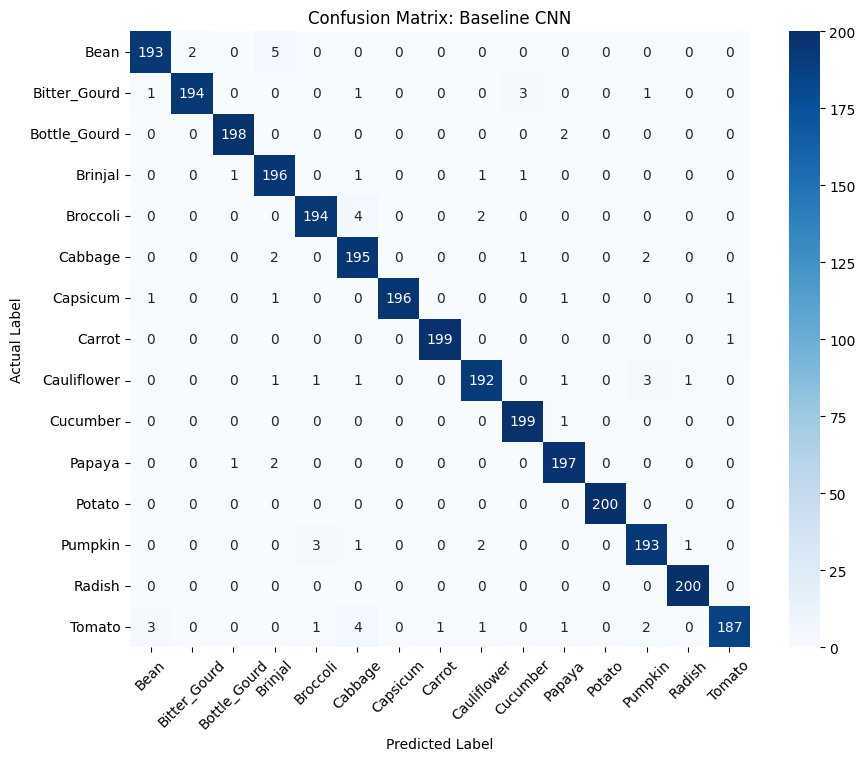

In [10]:
# Plotting the loss/accuracy curves
plot_training_history(baseline_history, "Baseline CNN")

# Getting the confusion matrix and precision/recall stats
evaluate_model_performance(baseline_model, test_generator, "Baseline CNN")

STEP 3: Deeper CNN with Regularization :

The baseline model might struggle with overfitting. To improve this, I'm building a deeper network (doubling the conv layers per block) and adding regularization techniques: Batch Normalization (after Conv layers) to stabilize training, Dropout to prevent neuron co-adaptation, and L2 Regularization on dense layers to penalize large weights.

In [11]:
deeper_model = Sequential([
    Input(shape=(224, 224, 3)),

    # Block 1
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(256, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.40),

    # Heavy Fully Connected Head
    Flatten(),

    Dense(512), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.5),
    Dense(256), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             

 Total params: 27,004,975 (103.02 MB)

 Trainable params: 27,001,519 (103.00 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [13]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_deeper_adam.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting training for Deeper CNN")
deeper_history = deeper_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks
)

Starting training for Deeper CNN
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.3729 - loss: 2.0520
Epoch 1: val_accuracy improved from None to 0.30967, saving model to best_deeper_adam.keras

Epoch 1: finished saving model to best_deeper_adam.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 274s 517ms/step - accuracy: 0.5187 - loss: 1.5171 - val_accuracy: 0.3097 - val_loss: 3.6665
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6983 - loss: 0.9265
Epoch 2: val_accuracy improved from 0.30967 to 0.68633, saving model to best_deeper_adam.keras

Epoch 2: finished saving model to best_deeper_adam.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 220s 468ms/step - accuracy: 0.7191 - loss: 0.8676 - val_accuracy: 0.6863 - val_loss: 0.9579
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.7849 - loss: 0.6610
Epoch 3: val_accuracy did not improve from 0.68633
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 471ms/step - accuracy: 0.8028 - loss: 0.6180 - val_accuracy: 0.6630 - val

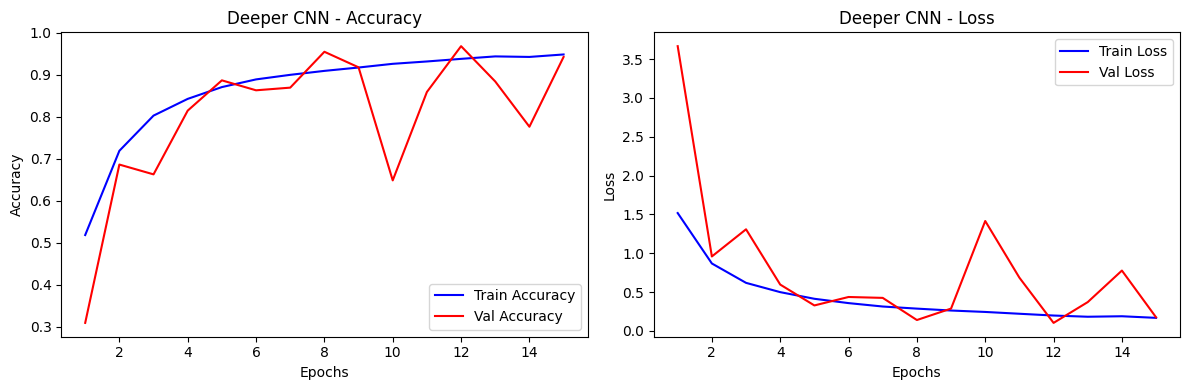

Evaluating Deeper CNN on Test Set
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step

1. Classification Report:

              precision    recall  f1-score   support

        Bean       0.89      0.99      0.94       200
Bitter_Gourd       0.95      0.98      0.97       200
Bottle_Gourd       0.99      0.99      0.99       200
     Brinjal       0.99      0.92      0.95       200
    Broccoli       0.98      0.98      0.98       200
     Cabbage       0.91      0.99      0.95       200
    Capsicum       0.98      0.98      0.98       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.99      0.94      0.97       200
    Cucumber       0.99      0.86      0.92       200
      Papaya       0.99      0.95      0.97       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.96      1.00      0.98       200
      Radish       0.99      0.99      0.99       200
      Tomato       0.96      0.96      0.96       200

    accuracy                    

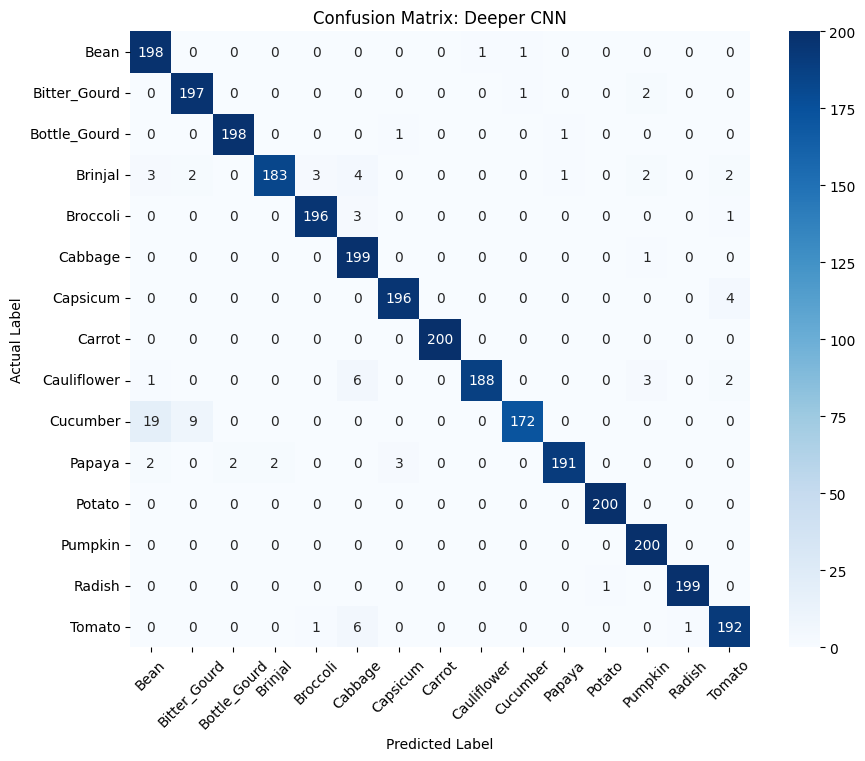

In [14]:
# Evaluating to see if BatchNorm and Dropout helped reduce overfitting
plot_training_history(deeper_history, "Deeper CNN")
evaluate_model_performance(deeper_model, test_generator, "Deeper CNN")

SGD


In [ ]:
from tensorflow.keras.optimizers import SGD

deeper_model_sgd = Sequential([
    Input(shape=(224, 224, 3)),

    # Block 1
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(256, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.40),

    # Fully Connected
    Flatten(),
    Dense(512), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.5),
    Dense(256), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

deeper_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model_sgd.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 56, 56, 128)    │             

 Total params: 27,004,975 (103.02 MB)

 Trainable params: 27,001,519 (103.00 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [ ]:

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_deeper_sgd.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Training Deeper CNN with SGD")
sgd_start = time.time()

sgd_history = deeper_model_sgd.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_sgd,
    verbose=1
)

sgd_time = time.time() - sgd_start
print(f"\nSGD Training time: {sgd_time:.2f}s ({sgd_time/60:.1f} min)")

Training Deeper CNN with SGD
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 257s 531ms/step - accuracy: 0.4607 - loss: 1.6953 - val_accuracy: 0.6450 - val_loss: 0.9646
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 471ms/step - accuracy: 0.6786 - loss: 0.9792 - val_accuracy: 0.5830 - val_loss: 1.3286
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 472ms/step - accuracy: 0.7486 - loss: 0.7747 - val_accuracy: 0.8440 - val_loss: 0.4674
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 218s 466ms/step - accuracy: 0.8127 - loss: 0.5865 - val_accuracy: 0.7927 - val_loss: 0.6373
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 462ms/step - accuracy: 0.8454 - loss: 0.4931 - val_accuracy: 0.7567 - val_loss: 0.8420
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 218s 465ms/step - accuracy: 0.8687 - loss: 0.4118 - val_accuracy: 0.9540 - val_loss: 0.1522
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 230s 491ms/step - accuracy: 0.8882 - loss: 0.3522 - val_accuracy: 0.9487 - val_loss: 0.1669
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 47

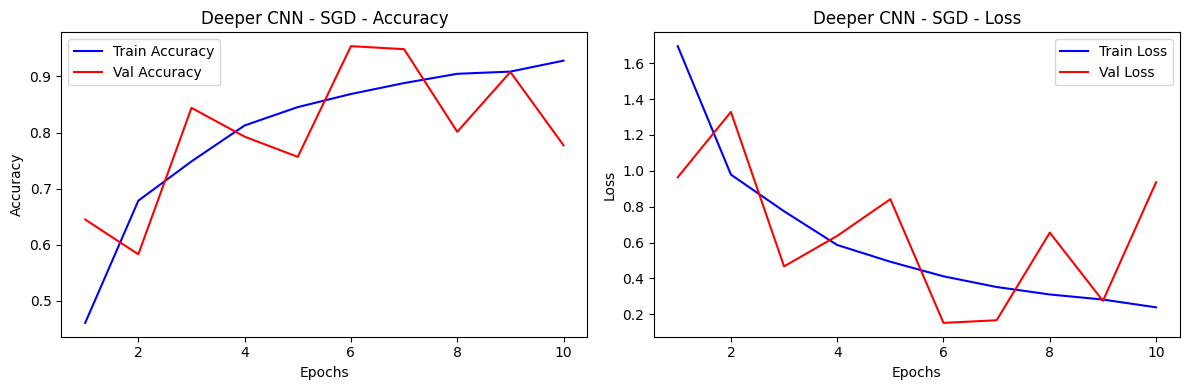

Evaluating Deeper CNN - SGD on Test Set
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step

1. Classification Report:

              precision    recall  f1-score   support

        Bean       0.90      0.96      0.93       200
Bitter_Gourd       1.00      0.94      0.97       200
Bottle_Gourd       0.98      0.91      0.94       200
     Brinjal       0.96      0.86      0.91       200
    Broccoli       0.98      0.95      0.97       200
     Cabbage       0.81      0.99      0.89       200
    Capsicum       0.99      0.97      0.98       200
      Carrot       0.99      0.96      0.98       200
 Cauliflower       0.96      0.92      0.94       200
    Cucumber       0.97      0.94      0.95       200
      Papaya       0.85      0.96      0.90       200
      Potato       0.97      0.99      0.98       200
     Pumpkin       0.97      0.96      0.97       200
      Radish       0.99      0.99      0.99       200
      Tomato       0.96      0.91      0.93       200

    accuracy              

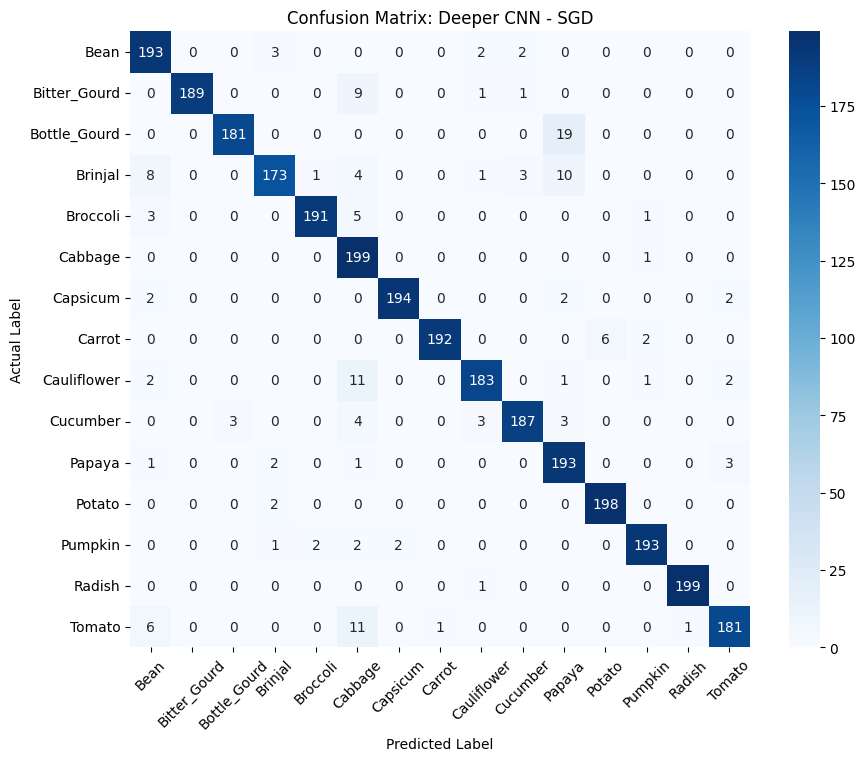

In [ ]:
plot_training_history(sgd_history, "Deeper CNN - SGD")
evaluate_model_performance(deeper_model_sgd, test_generator, "Deeper CNN - SGD")

Transfer Learning


In [15]:
import time
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

 MobileNetV2-specific Data Generators

In [16]:
# MobileNetV2 expects pixel values in [-1, 1] via its own preprocess_input,
# NOT the standard rescale=1./255 used in Part A.
# We rebuild generators with the correct preprocessing function.

mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

mobilenet_val_test_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess
)

print("Loading Training Data (MobileNetV2 preprocessing):")
mobilenet_train_gen = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,        # (224, 224) — matches MobileNetV2 input
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\nLoading Validation Data (MobileNetV2 preprocessing):")
mobilenet_val_gen = mobilenet_val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nLoading Test Data (MobileNetV2 preprocessing):")
mobilenet_test_gen = mobilenet_val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Loading Training Data (MobileNetV2 preprocessing):
Found 15000 images belonging to 15 classes.

Loading Validation Data (MobileNetV2 preprocessing):
Found 3000 images belonging to 15 classes.

Loading Test Data (MobileNetV2 preprocessing):
Found 3000 images belonging to 15 classes.


Load MobileNetV2 base & build Feature Extraction model

In [17]:
# Load MobileNetV2 pretrained on ImageNet
# All convolutional base layers are FROZEN

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,           # Remove the original 1000-class classifier
    weights='imagenet'
)
base_model.trainable = False     # Freeze the entire convolutional base

print(f"MobileNetV2 base loaded — {len(base_model.layers)} layers, all frozen.")

# Build the classification head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)   # training=False keeps BN layers frozen
x = GlobalAveragePooling2D()(x)          # Replace Flatten — more efficient
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)  # 15 classes

mobilenet_feature_model = Model(inputs, outputs, name='MobileNetV2_FeatureExtraction')
mobilenet_feature_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base loaded — 154 layers, all frozen.


Model: "MobileNetV2_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,751 (10.00 MB)

 Trainable params: 362,767 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobilenet_feature_model.compile(
    optimizer=Adam(learning_rate=1e-3),   # Higher LR fine for frozen base
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fe = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mobilenet_fe.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("Phase 1: Feature Extraction Training")
fe_start = time.time()

fe_history = mobilenet_feature_model.fit(
    mobilenet_train_gen,
    epochs=20,
    validation_data=mobilenet_val_gen,
    callbacks=callbacks_fe,
    verbose=1
)

fe_time = time.time() - fe_start
print(f"\nFeature extraction training time: {fe_time:.2f}s ({fe_time/60:.1f} min)")





Phase 1: Feature Extraction Training
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7799 - loss: 0.7213
Epoch 1: val_accuracy improved from None to 0.99267, saving model to best_mobilenet_fe.keras

Epoch 1: finished saving model to best_mobilenet_fe.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 239s 462ms/step - accuracy: 0.9037 - loss: 0.3171 - val_accuracy: 0.9927 - val_loss: 0.0246
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9739 - loss: 0.0943
Epoch 2: val_accuracy improved from 0.99267 to 0.99767, saving model to best_mobilenet_fe.keras

Epoch 2: finished saving model to best_mobilenet_fe.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 414ms/step - accuracy: 0.9748 - loss: 0.0870 - val_accuracy: 0.9977 - val_loss: 0.0102
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9817 - loss: 0.0606
Epoch 3: val_accuracy improved from 0.99767 to 0.99800, saving model to best_mobilenet_fe.keras

Epoch 3: finished saving model to best_mobilenet_fe.k

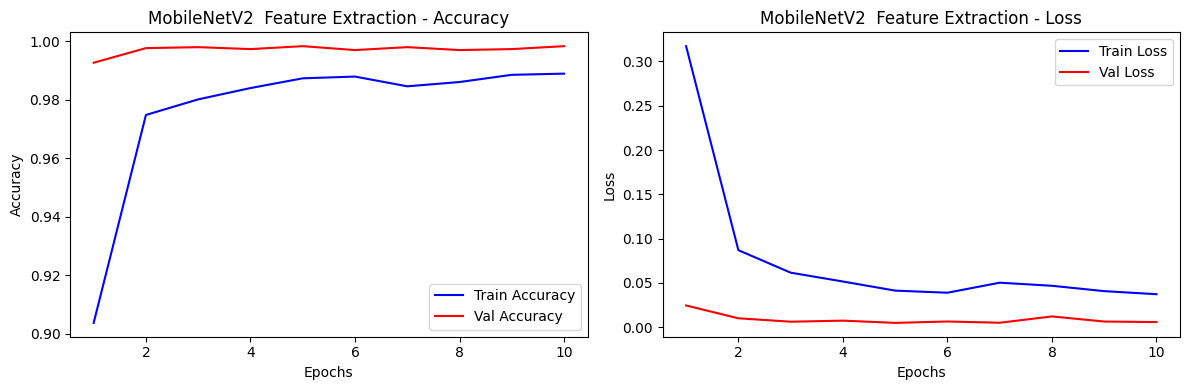

Evaluating MobileNetV2  Feature Extraction on Test Set
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step

1. Classification Report:

              precision    recall  f1-score   support

        Bean       0.99      1.00      1.00       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      0.99      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.99      0.99      0.99       200
    Cucumber       0.99      0.98      0.99       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.99      0.99      0.99       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      0.99      0.99       200

    accurac

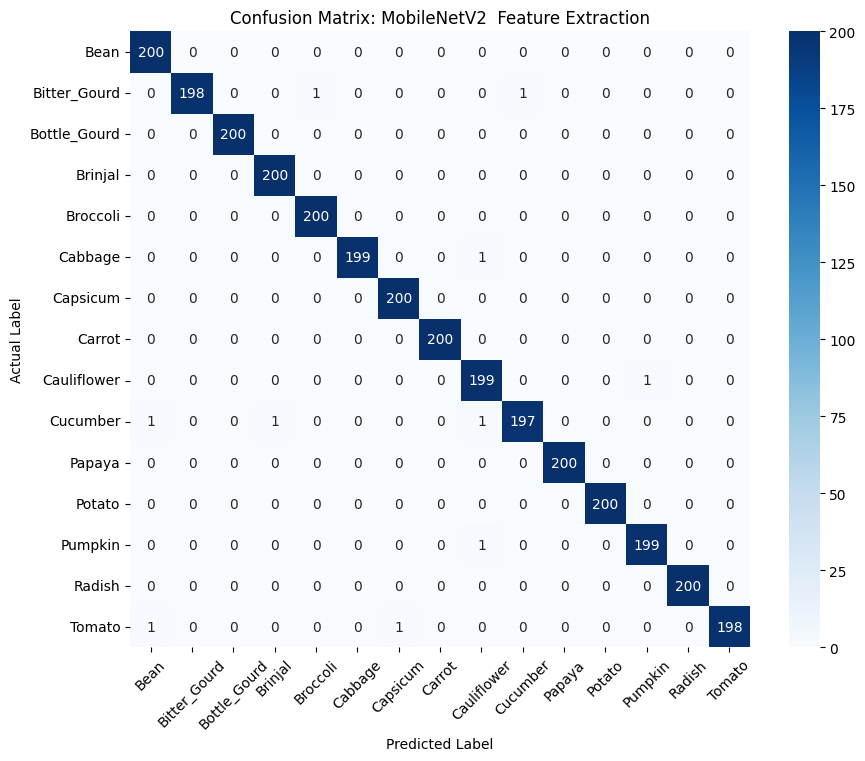

In [ ]:
plot_training_history(fe_history, "MobileNetV2  Feature Extraction")
evaluate_model_performance(mobilenet_feature_model, mobilenet_test_gen, "MobileNetV2  Feature Extraction")

Fine-Tuning: unfreeze top 30 layers

In [19]:
# Unfreeze top 30 layers of MobileNetV2 base with a very low LR
# to avoid catastrophic forgetting
base_model.trainable = True
# Freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning: {trainable_count} of {len(base_model.layers)} base layers now trainable.")

# Recompile with much lower LR
mobilenet_feature_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mobilenet_ft.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("\nFine-Tuning Training")
ft_start = time.time()

ft_history = mobilenet_feature_model.fit(
    mobilenet_train_gen,
    epochs=20,
    validation_data=mobilenet_val_gen,
    callbacks=callbacks_ft,
    verbose=1
)

ft_time = time.time() - ft_start
print(f"\nFine-tuning training time: {ft_time:.2f}s ({ft_time/60:.1f} min)")

Fine-tuning: 30 of 154 base layers now trainable.

Fine-Tuning Training
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.1881 - loss: 2.6524
Epoch 1: val_accuracy improved from None to 0.87667, saving model to best_mobilenet_ft.keras

Epoch 1: finished saving model to best_mobilenet_ft.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 237s 466ms/step - accuracy: 0.3399 - loss: 2.1840 - val_accuracy: 0.8767 - val_loss: 1.0159
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7281 - loss: 1.0865
Epoch 2: val_accuracy improved from 0.87667 to 0.96200, saving model to best_mobilenet_ft.keras

Epoch 2: finished saving model to best_mobilenet_ft.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 415ms/step - accuracy: 0.7821 - loss: 0.8854 - val_accuracy: 0.9620 - val_loss: 0.2066
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8827 - loss: 0.4844
Epoch 3: val_accuracy improved from 0.96200 to 0.97900, saving model to best_mobilenet_ft.keras

Epoch 3: finished 

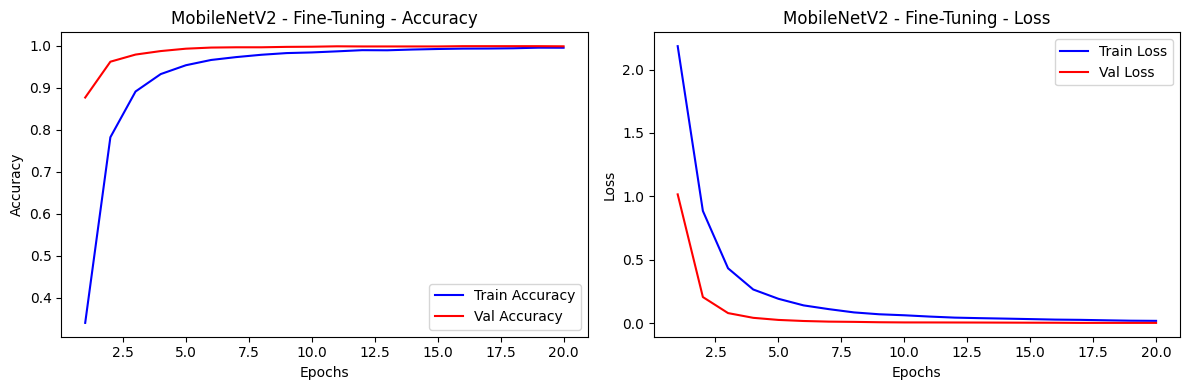

In [20]:
plot_training_history(ft_history, "MobileNetV2 - Fine-Tuning")